## EXAM REQUIREMENTS:

DATASET: Housing.csv (house prices)

PART 1- Load and inspect data
PART 2- Clean the data (missing values, duplicates, outliers using IQR)
PART 3- Answer 10 analysis questions
PART 4- Create 5 visualizations
PART 5- Write a 400 - 600 Word report

Part 1 of the exam is to load and inspect data. So we import our tools first and then load the csv file

In [1]:
#import our tools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load the housing dataset into a dataframe
#pd.read_csv converts the file into a table we can work with

df = pd.read_csv("/kaggle/input/datasets/kryusufkaya/housing/Housing.csv")

#Display the first 10 rows. This gives us a first look at the data
print(df.head(10))

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

In [2]:
#Check Shape...this tells us how many rows and colums exist in the date

print(df.shape)

(545, 13)


In [3]:
#check data types..this shows what type of data each column contains- integer, float, objecct

print(df.dtypes)

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [4]:
#Summary ststistics. we use #describe# for this and it automatially calculates the sum, mean,
#std,min and max for all numerical columns in the data. It is a quick statistical overview.

print(df.describe)


<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       

In [5]:
#Check median separetely

print(df.median(numeric_only=True))

price        4340000.0
area            4600.0
bedrooms           3.0
bathrooms          1.0
stories            2.0
parking            0.0
dtype: float64


In [6]:
#find unique values for categorical columns
#categorical columns contains text like yes/no. We need to see what values exist in each.
#First, let us find which columns are categorical -object type.

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(df[column].value_counts())

mainroad
yes    468
no      77
Name: count, dtype: int64
guestroom
no     448
yes     97
Name: count, dtype: int64
basement
no     354
yes    191
Name: count, dtype: int64
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning
no     373
yes    172
Name: count, dtype: int64
prefarea
no     417
yes    128
Name: count, dtype: int64
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


Part 2 of the Exam is Data Cleaning....we check for missing values, duplicate rows and outliers. Then we verify categorical columns and write a data quality summary

In [7]:
# Check for missing values in every column
# isnull() finds empty cells
# .sum() counts them per column

print("Missing values per column:")
missing = df.isnull().sum()
print(missing)

# Calculate percentage missing
print("\nPercentage missing:")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Percentage missing:
price               0.0
area                0.0
bedrooms            0.0
bathrooms           0.0
stories             0.0
mainroad            0.0
guestroom           0.0
basement            0.0
hotwaterheating     0.0
airconditioning     0.0
parking             0.0
prefarea            0.0
furnishingstatus    0.0
dtype: float64


After checking all rows and columns, the datase contains no missing values. Every column shows 0 missing entries and 0.00 missing percentage. The dataset is complete and no imputation or filling is required.

In [8]:
# Check for duplicate rows
# duplicated() finds rows that are exact copies

print("Number of duplicate rows:")
duplicates = df.duplicated().sum()
print(duplicates)

# If duplicates exist — remove them
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"\n{duplicates} duplicate rows removed!")
    print(f"New shape: {df.shape}")
else:
    print("\nNo duplicate rows found! Dataset is clean.")

Number of duplicate rows:
0

No duplicate rows found! Dataset is clean.


In [9]:
# CHECKING OUTLIERS IN PRICE USING IQR METHOD

# Step 1 — Calculate Q1 and Q3 for price
Q1_price = df["price"].quantile(0.25)
Q3_price = df["price"].quantile(0.75)

# Step 2 — Calculate IQR
IQR_price = Q3_price - Q1_price

# Step 3 — Calculate the fences
lower_fence_price = Q1_price - (1.5 * IQR_price)
upper_fence_price = Q3_price + (1.5 * IQR_price)

# Step 4 — Find outliers
price_outliers = df[(df["price"] < lower_fence_price) |
                    (df["price"] > upper_fence_price)]

print("=== PRICE OUTLIER ANALYSIS ===")
print(f"Q1: {Q1_price:,.0f}")
print(f"Q3: {Q3_price:,.0f}")
print(f"IQR: {IQR_price:,.0f}")
print(f"Lower Fence: {lower_fence_price:,.0f}")
print(f"Upper Fence: {upper_fence_price:,.0f}")
print(f"Number of outliers: {len(price_outliers)}")


# NOW DO THE SAME FOR AREA
Q1_area = df["area"].quantile(0.25)
Q3_area = df["area"].quantile(0.75)
IQR_area = Q3_area - Q1_area

lower_fence_area = Q1_area - (1.5 * IQR_area)
upper_fence_area = Q3_area + (1.5 * IQR_area)

area_outliers = df[(df["area"] < lower_fence_area) |
                   (df["area"] > upper_fence_area)]

print("\n=== AREA OUTLIER ANALYSIS ===")
print(f"Q1: {Q1_area:,.0f}")
print(f"Q3: {Q3_area:,.0f}")
print(f"IQR: {IQR_area:,.0f}")
print(f"Lower Fence: {lower_fence_area:,.0f}")
print(f"Upper Fence: {upper_fence_area:,.0f}")
print(f"Number of outliers: {len(area_outliers)}")

=== PRICE OUTLIER ANALYSIS ===
Q1: 3,430,000
Q3: 5,740,000
IQR: 2,310,000
Lower Fence: -35,000
Upper Fence: 9,205,000
Number of outliers: 15

=== AREA OUTLIER ANALYSIS ===
Q1: 3,600
Q3: 6,360
IQR: 2,760
Lower Fence: -540
Upper Fence: 10,500
Number of outliers: 12


Using the IQR method,we identified 15 price outliers- houses priced above 9.2 million which are significantly more expensive than typcial properties. We also found 12 area outliers- properties larger than 10,500 sq ft. Since these could represent genuine loxury properties rathan than data errors, they will be retained in the dataset but we will note their existence because their presence can influence average price calculations.

In [10]:
# Verify categorical columns contain only expected values
# These columns should ONLY have 'yes' or 'no'

yes_no_columns = ["mainroad", "guestroom", "basement",
                  "hotwaterheating", "airconditioning", "prefarea"]

print("=== CHECKING YES/NO COLUMNS ===")
for col in yes_no_columns:
    unique_vals = df[col].unique()
    print(f"{col}: {unique_vals}")

# Check furnishing status separately
# It should have 3 values: furnished, semi-furnished, unfurnished
print(f"\nfurnishingstatus: {df['furnishingstatus'].unique()}")

=== CHECKING YES/NO COLUMNS ===
mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']

furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


## Data Quality Summary

After a thorough inspection of the Housing dataset:

1. MISSING VALUES: No missing values were found across 
   all 13 columns. The dataset is 100% complete.

2. DUPLICATES: No duplicate rows were found. All 545 
   records are unique.

3. OUTLIERS: Using the IQR method, we identified 15 
   price outliers (above 9,205,000) and 12 area outliers 
   (above 10,500 sq ft). These likely represent genuine 
   luxury properties and were retained for analysis.

4. CATEGORICAL VALUES: All yes/no columns contain only 
   'yes' or 'no' values. The furnishingstatus column 
   correctly contains exactly 3 categories: furnished, 
   semi-furnished, and unfurnished.

CONCLUSION: The dataset is clean and ready for analysis.
No data corrections were required

PART 3 contains 10 analytical questions derived from the dataset. The answer to each questions needs the code, the output and 2 sentences min of interpretation.

In [11]:
# Q1: What is the average, median and maximum house price?

avg_price = df["price"].mean()
median_price = df["price"].median()
max_price = df["price"].max()

print("=== HOUSE PRICE STATISTICS ===")
print(f"Average Price:  {avg_price:,.0f}")
print(f"Median Price:   {median_price:,.0f}")
print(f"Maximum Price:  {max_price:,.0f}")

=== HOUSE PRICE STATISTICS ===
Average Price:  4,766,729
Median Price:   4,340,000
Maximum Price:  13,300,000


The average house price is 4,766,729 while the median is 4,340,000. The average is higher than the median because a small number of very expensive houses, like the maximum price of 13,300,000 pulls the average upward. This confirms the presence of the 15 price outliers we identified in Part 2. The median is a more reliable measure of typical house price in this dataset.

In [12]:
# Q2: What is the correlation between area and price?

# .corr() calculates correlation between two columns

correlation = df["area"].corr(df["price"])

print("=== AREA vs PRICE CORRELATION ===")
print(f"Correlation coefficient: {correlation:.4f}")

# Interpret the strength
if correlation >= 0.7:
    strength = "Strong positive"
elif correlation >= 0.4:
    strength = "Moderate positive"
elif correlation >= 0:
    strength = "Weak positive"
else:
    strength = "Negative"

print(f"Interpretation: {strength} correlation")

=== AREA vs PRICE CORRELATION ===
Correlation coefficient: 0.5360
Interpretation: Moderate positive correlation


the correlation between area and price is 0.54 is a moderate positive correlation. This means that as house area increases, price tends to increase too. However, the relationship is not very strong, suggesting that area alone does not determine price and other features like location and amenities also play important roles."

In [13]:
# Q3: What are the top 5 most expensive houses?
# What features do they share?

# Sort by price descending and get top 5
top5 = df.nlargest(5, "price")

print("=== TOP 5 MOST EXPENSIVE HOUSES ===")
print(top5[["price", "area", "bedrooms",
            "bathrooms", "stories",
            "mainroad", "airconditioning",
            "furnishingstatus"]].to_string(index=False))

=== TOP 5 MOST EXPENSIVE HOUSES ===
   price  area  bedrooms  bathrooms  stories mainroad airconditioning furnishingstatus
13300000  7420         4          2        3      yes             yes        furnished
12250000  8960         4          4        4      yes             yes        furnished
12250000  9960         3          2        2      yes              no   semi-furnished
12215000  7500         4          2        2      yes             yes        furnished
11410000  7420         4          1        2      yes             yes        furnished


The top 5 most expensive houses range from 11,410,000 to 13,300,000. They share several common features, which is all 5 are located on the main road, 4 out of 5 have air conditioning, and 4 out of 5 are fully furnished. Most have 4 bedrooms and multiple stories. This suggests that main road location, air conditioning and furnishing status are key drivers of high house prices."

In [14]:
# Q4: Do houses on the main road sell for more?
# Compare average prices

mainroad_price = df.groupby("mainroad")["price"].mean()

print("=== AVERAGE PRICE BY MAIN ROAD ===")
print(mainroad_price.apply(lambda x: f"{x:,.0f}"))

# Calculate the difference
diff = mainroad_price["yes"] - mainroad_price["no"]
print(f"\nPrice premium for main road: {diff:,.0f}")

=== AVERAGE PRICE BY MAIN ROAD ===
mainroad
no     3,398,905
yes    4,991,777
Name: price, dtype: object

Price premium for main road: 1,592,873


Houses located on the main road command significantly higher prices, averaging 4,991,777 compared to 3,398,905 for non-main road properties. This represents a price premium of 1,592,873 which is approximately 47% more expensive. Main road location is clearly a major factor in determining house price.

In [15]:
# Q5: Does air conditioning significantly affect price?

ac_price = df.groupby("airconditioning")["price"].mean()

print("=== AVERAGE PRICE BY AIR CONDITIONING ===")
print(ac_price.apply(lambda x: f"{x:,.0f}"))

diff_ac = ac_price["yes"] - ac_price["no"]
print(f"\nPrice premium for AC: {diff_ac:,.0f}")

=== AVERAGE PRICE BY AIR CONDITIONING ===
airconditioning
no     4,191,940
yes    6,013,221
Name: price, dtype: object

Price premium for AC: 1,821,281


Houses with air conditioning are significantly more expensive, averaging 6,013,221 compared to 4,191,940 without AC. This represents a premium of 1,821,281, making air conditioning the single biggest price driver we've found so far, even larger than main road location.

In [16]:
# Q6: How does furnishing status affect price?
# Show average price for each category and rank them

furnishing_price = df.groupby("furnishingstatus")["price"].mean()

# Sort from highest to lowest
furnishing_price = furnishing_price.sort_values(ascending=False)

print("=== AVERAGE PRICE BY FURNISHING STATUS ===")
print("(Ranked highest to lowest)")
for status, price in furnishing_price.items():
    print(f"{status:20} → {price:,.0f}")

=== AVERAGE PRICE BY FURNISHING STATUS ===
(Ranked highest to lowest)
furnished            → 5,495,696
semi-furnished       → 4,907,524
unfurnished          → 4,013,831


Furnishing status clearly affects house price. Fully furnished houses average 5,495,696 which is the highest, followed by semi-furnished at 4,907,524 and unfurnished at 4,013,831. The gap between furnished and unfurnished is 1,481,865, confirming that furnishing status is a significant factor in house pricing.

In [17]:
# Q7: Do houses in preferred area command a price premium?

prefarea_price = df.groupby("prefarea")["price"].mean()

print("=== AVERAGE PRICE BY PREFERRED AREA ===")
print(prefarea_price.apply(lambda x: f"{x:,.0f}"))

diff_pref = prefarea_price["yes"] - prefarea_price["no"]
percentage = (diff_pref / prefarea_price["no"]) * 100

print(f"\nPrice premium for preferred area: {diff_pref:,.0f}")
print(f"Percentage premium: {percentage:.1f}%")

=== AVERAGE PRICE BY PREFERRED AREA ===
prefarea
no     4,425,299
yes    5,879,046
Name: price, dtype: object

Price premium for preferred area: 1,453,747
Percentage premium: 32.9%


Houses in preferred areas command a significant price premium, averaging 5,879,046 compared to 4,425,299 in non-preferred areas. This represents a premium of 1,453,747 which is approximately 32.9% more expensive. Location preference is clearly a strong driver of house prices."

In [18]:
# Q8: Most common number of bedrooms?
# What percentage have exactly 3 bedrooms?

bedroom_counts = df["bedrooms"].value_counts()
print("=== BEDROOM DISTRIBUTION ===")
print(bedroom_counts)

most_common = df["bedrooms"].mode()[0]
three_bed_count = len(df[df["bedrooms"] == 3])
three_bed_pct = (three_bed_count / len(df)) * 100

print(f"\nMost common: {most_common} bedrooms")
print(f"Houses with exactly 3 bedrooms: {three_bed_count}")
print(f"Percentage with 3 bedrooms: {three_bed_pct:.1f}%")

=== BEDROOM DISTRIBUTION ===
bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64

Most common: 3 bedrooms
Houses with exactly 3 bedrooms: 300
Percentage with 3 bedrooms: 55.0%


3 bedrooms is the most common configuration, appearing in 300 out of 545 houses which is exactly 55% of the dataset. This suggests the market is dominated by medium-sized family homes.

In [19]:
# Q9: Houses with BOTH basement AND airconditioning
both = df[(df["basement"] == "yes") &
          (df["airconditioning"] == "yes")]

print("\n=== BASEMENT AND AC ===")
print(f"Houses with both: {len(both)}")
print(f"Average price: {both['price'].mean():,.0f}")


=== BASEMENT AND AC ===
Houses with both: 66
Average price: 6,081,197


Only 66 houses have both a basement and air conditioning. However these premium properties command an average price of 6,081,197 — significantly above the dataset average of 4,766,729, confirming that combined amenities drive prices substantially higher.

In [20]:
# Q10: Relationship between stories and price
stories_price = df.groupby("stories")["price"].mean()
print("\n=== AVERAGE PRICE BY NUMBER OF STORIES ===")
for stories, price in stories_price.items():
    print(f"{stories} stories → {price:,.0f}")


=== AVERAGE PRICE BY NUMBER OF STORIES ===
1 stories → 4,170,659
2 stories → 4,764,074
3 stories → 5,685,436
4 stories → 7,208,450


There is a clear positive trend, as the number of stories increases, price increases consistently. 4-storey houses average 7,208,450 — nearly double the 4,170,659 average of single-storey properties. More stories strongly correlates with higher price."

 Part 4: Visualisations!
 5 charts are required.
Histogram — price distribution
Scatter plot — area vs price by furnishing
Box plot — price by airconditioning
Bar chart — average price by bedrooms
Heatmap — correlations between all numeric variables

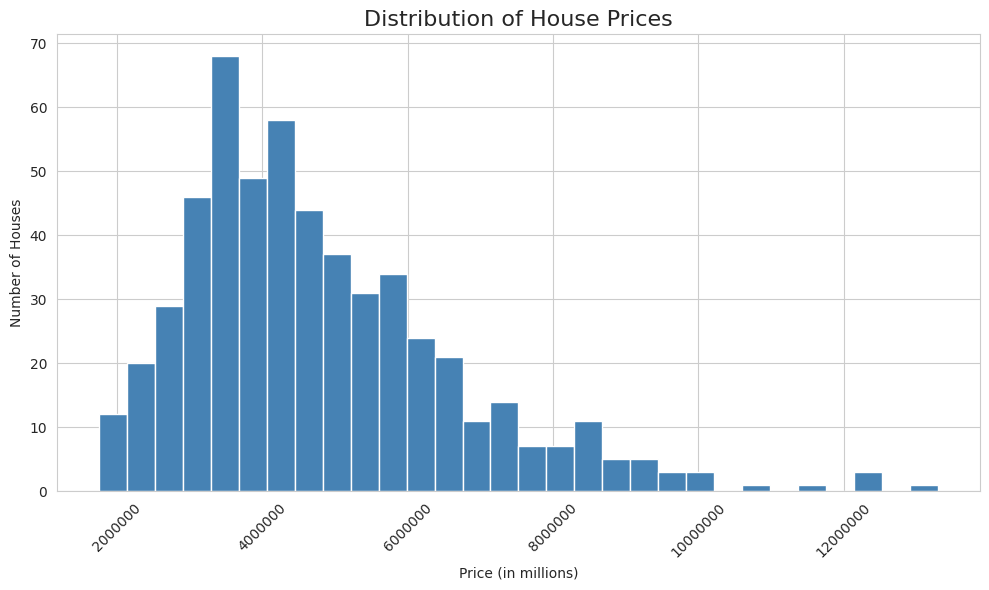

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

plt.hist(df["price"], bins=30,
         color="steelblue", edgecolor="white")

plt.title("Distribution of House Prices", fontsize=16)
plt.xlabel("Price (in millions)")
plt.ylabel("Number of Houses")

# This formats the x-axis numbers properly
plt.ticklabel_format(style="plain", axis="x")

# Rotate x labels so they don't overlap
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The price distribution is right-skewed, meaning most houses are priced between 2-7 million, with a small number of very expensive properties pulling the tail to the right. This confirms the outliers identified in Part 2.

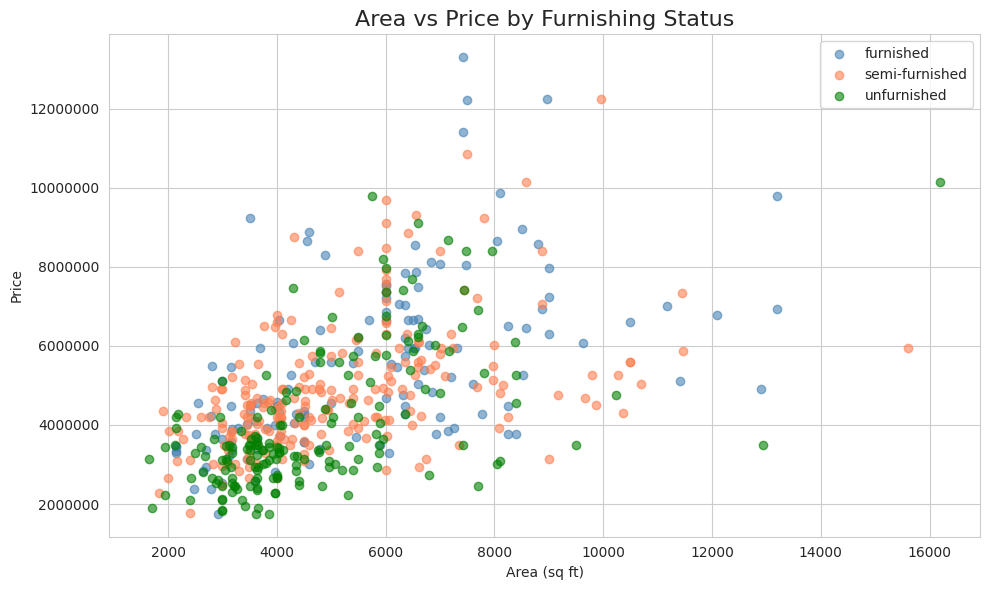

In [22]:
# Chart 2: Area vs Price coloured by furnishing status

plt.figure(figsize=(10, 6))

# Get unique furnishing categories
furnishing_types = df["furnishingstatus"].unique()
colors = ["steelblue", "coral", "green"]

for i, status in enumerate(furnishing_types):
    subset = df[df["furnishingstatus"] == status]
    plt.scatter(subset["area"],
                subset["price"],
                label=status,
                color=colors[i],
                alpha=0.6)

plt.title("Area vs Price by Furnishing Status", fontsize=16)
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.tight_layout()
plt.show()

The scatter plot reveals that furnished houses (blue) generally command higher prices regardless of area, while unfurnished properties (green) cluster at lower price points. There is a moderate positive trend between area and price, consistent with the 0.54 correlation found in Part 3. A few high-value outliers are visible at the top of the chart."

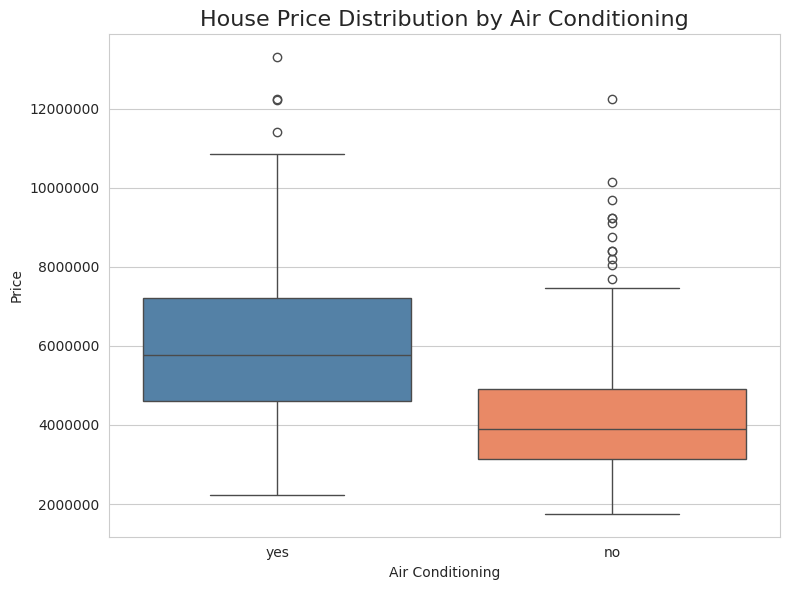

In [23]:
# Chart 3: Price by air conditioning box plot (yes/no)

plt.figure(figsize=(8, 6))

sns.boxplot(x="airconditioning",
            y="price",
            data=df,
            hue="airconditioning",
            palette={"yes": "steelblue", "no": "coral"},
            legend=False)

plt.title("House Price Distribution by Air Conditioning",
          fontsize=16)
plt.xlabel("Air Conditioning")
plt.ylabel("Price")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

The box plot clearly shows that houses with air conditioning (blue) have significantly higher and more spread out prices compared to those without (coral). The median price for AC houses sits around 5,800,000 versus 3,800,000 for non-AC houses. The dots above both boxes represent outlier properties priced unusually high, confirming the 15 price outliers identified in Part 2."

In [ ]:
# Chart 4: Average price by number of bedrooms

plt.figure(figsize=(10, 6))

bedroom_price = df.groupby("bedrooms")["price"].mean()

plt.bar(bedroom_price.index,
        bedroom_price.values,
        color="steelblue",
        edgecolor="white")

plt.title("Average House Price by Number of Bedrooms",
          fontsize=16)
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(bedroom_price.index)
plt.tight_layout()
plt.show()

The bar chart shows that average house price generally increases with the number of bedrooms. However the relationship is not perfectly linear, 6-bedroom houses show a dip, likely because very few such properties exist in the dataset, making the average less reliable.

In [ ]:
# Chart 5: Correlation heatmap of all numeric variables

plt.figure(figsize=(10, 8))

# Select only numeric columns
numeric_df = df.select_dtypes(include="number")

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix,
            annot=True,        # shows numbers inside boxes
            fmt=".2f",         # rounds to 2 decimal places
            cmap="coolwarm",   # red=positive, blue=negative
            center=0,          # white = zero correlation
            square=True)       # makes boxes square

plt.title("Correlation Matrix of Numeric Variables",
          fontsize=16)
plt.tight_layout()
plt.show()

The heatmap displays correlations between all numeric variables. Warmer colours (red) indicate positive correlations while cooler colours (blue) indicate negative or weak correlations. Price shows the strongest correlation with area (0.54), followed by the number of bathrooms (0.52) and stories (0.42). Bedrooms show a surprisingly weak correlation with price (0.37), suggesting size and amenities matter more than bedroom count alone.